# Isolation Forest for Anomaly Detection  
### Financial Transaction Analysis  

**Student ID: 24076688**

#### **Student name: Saisahasri Mudireddy**
---

## Objective
This tutorial demonstrates how Isolation Forest detects anomalies in financial transaction data, helping identify fraudulent activities.

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.datasets import make_blobs

### Generate Dataset(Financial)

In [2]:
X, _ = make_blobs(n_samples=300, centers=1, cluster_std=1.0, random_state=42)

# Add anomalies
rng = np.random.RandomState(42)
anomalies = rng.uniform(low=-6, high=6, size=(20, 2))

X = np.vstack([X, anomalies])

### Raw Data

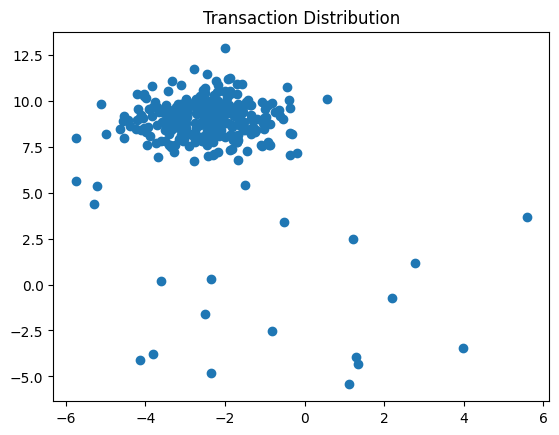

In [9]:
plt.scatter(X[:,0], X[:,1])
plt.title("Transaction Distribution")
plt.savefig("transaction_distribution.png")
plt.show()

### ISOLATION FOREST MODEL

In [4]:
iso = IsolationForest(contamination=0.05, random_state=42)
labels = iso.fit_predict(X)

### Anomalies

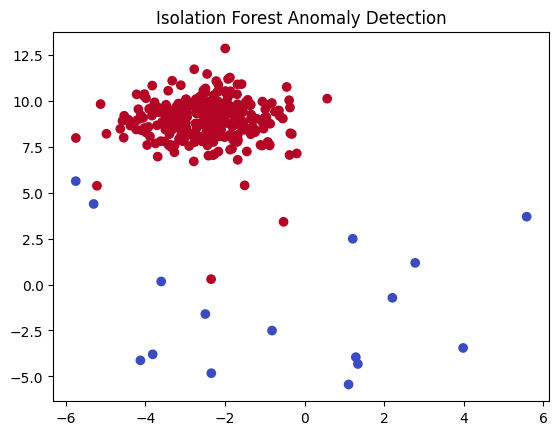

In [10]:
plt.scatter(X[:,0], X[:,1], c=labels, cmap='coolwarm')
plt.title("Isolation Forest Anomaly Detection")
plt.savefig("isolation_forest_anomaly_detection.png")
plt.show()

### Highlight Anomalies

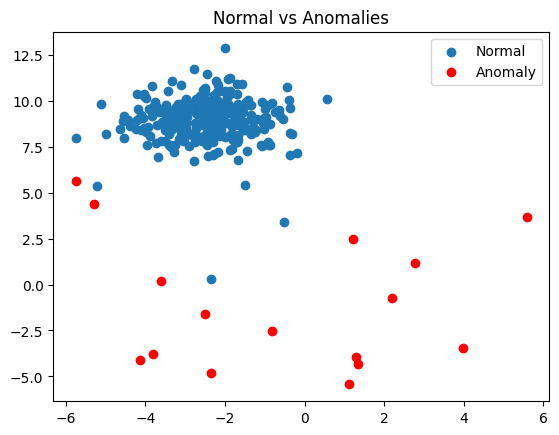

In [11]:
normal = labels == 1
anomaly = labels == -1

plt.scatter(X[normal,0], X[normal,1], label="Normal")
plt.scatter(X[anomaly,0], X[anomaly,1], color='red', label="Anomaly")

plt.legend()
plt.title("Normal vs Anomalies")
plt.savefig("normal_vs_anomalies.png")
plt.show()

### Anomaly Scores

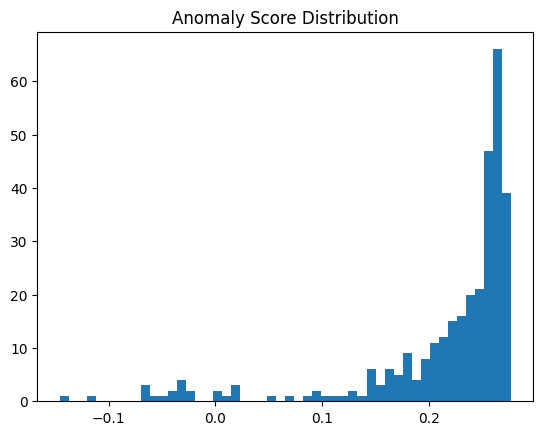

In [12]:
scores = iso.decision_function(X)

plt.hist(scores, bins=50)
plt.title("Anomaly Score Distribution")
plt.savefig("anomaly_score_distribution.png")
plt.show()

### Contamination Effect

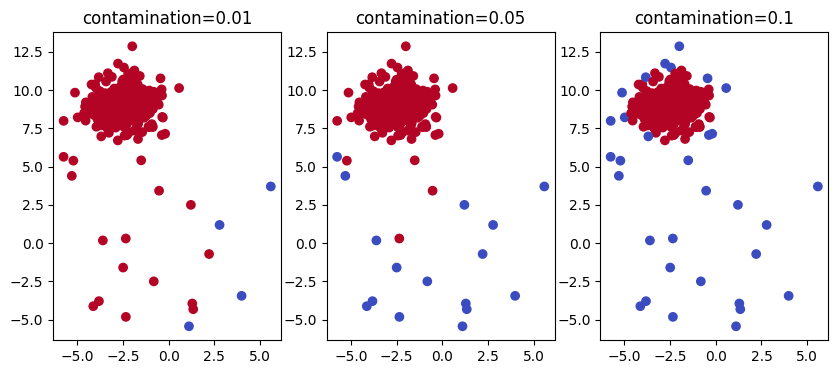

In [13]:
contamination_values = [0.01, 0.05, 0.1]

plt.figure(figsize=(10,4))

for i, c in enumerate(contamination_values):
    model = IsolationForest(contamination=c, random_state=42)
    labels_temp = model.fit_predict(X)

    plt.subplot(1,3,i+1)
    plt.scatter(X[:,0], X[:,1], c=labels_temp, cmap='coolwarm')
    plt.title(f"contamination={c}")
plt.savefig("contamination_effect.png")
plt.show()

## Key Insights

- Isolation Forest isolates anomalies instead of grouping data
- Anomalies are easier to isolate → shorter path lengths
- Contamination parameter controls sensitivity
- Useful for fraud detection and risk analysis